# Data Analysis

In this analysis we will explore NBA data to undrestand it.

In [62]:
import pandas as pd
from sqlite3 import connect

from scipy.stats import shapiro, ttest_ind, mannwhitneyu, f_oneway

import seaborn as sns
import matplotlib.pyplot as plt

connecting to database

In [3]:
conn = connect('nba.db')

## Query 1: Distribution of Height

In [4]:
mvp_players_height = pd.read_sql("""SELECT height FROM players
                                    WHERE player_id IN (SELECT player_id FROM mvp)""", conn)

In [5]:
season_top_players_height = pd.read_sql("""SELECT height FROM players
                                           WHERE player_id IN (SELECT player_id FROM season_top_players
                                           WHERE season >= 2020 and
                                           season <= 2024 and
                                           rank <= 50)""", conn)

Text(0.5, 1.0, 'Distribution of Height of Players')

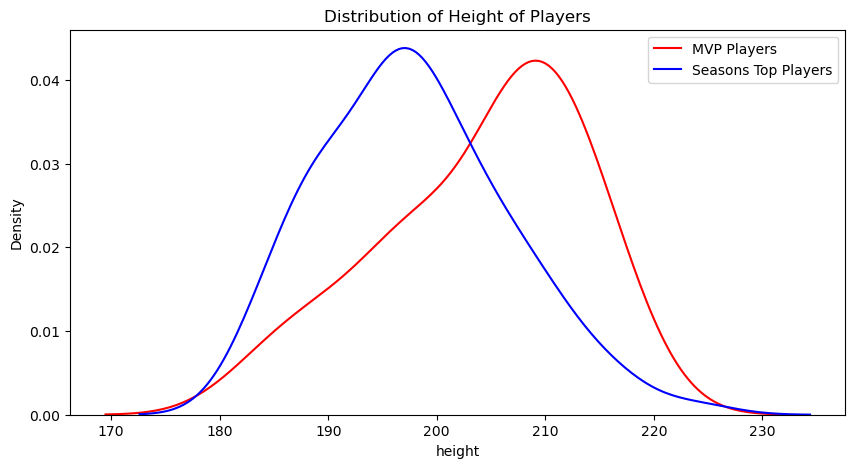

In [6]:
fig = plt.figure(figsize=(10, 5))

sns.kdeplot(mvp_players_height['height'], color='r', label='MVP Players')
sns.kdeplot(season_top_players_height['height'], color='b', label='Seasons Top Players')

plt.legend()
plt.title('Distribution of Height of Players')

## Query 2: Distribution of experience and height

we will get data related to champion team from players and team_players tables.

In [7]:
height_champ = pd.read_sql("""SELECT height FROM players
                              WHERE player_id IN (SELECT player_id FROM team_players
                              WHERE season = '2024-25' or season = '2023-24')
                               """, conn)

In [8]:
exprience_champ = pd.read_sql("""SELECT career_length FROM players
                              WHERE player_id IN (SELECT player_id FROM team_players
                              WHERE season = '2024-25' or season = '2023-24')
                               """, conn)

exprience_champ['career_length'] = exprience_champ['career_length'].str.extract(r'(\d+)').astype(int)


the data of top season players is available in season_top_players.

In [9]:
height_season = pd.read_sql("""SELECT height FROM players
                              WHERE player_id IN (SELECT player_id FROM season_top_players
                              WHERE (season = 2025 or season = 2024) and rank <= 15)
                               """, conn)


In [10]:
exprience_season = pd.read_sql("""SELECT career_length FROM players
                              WHERE player_id IN (SELECT player_id FROM season_top_players
                              WHERE (season = 2025 or season = 2024) and rank <= 15)
                               """, conn)

exprience_season['career_length'] = exprience_season['career_length'].str.extract(r'(\d+)').astype(int)


Text(0.5, 1.0, 'Distribution of Height of Players')

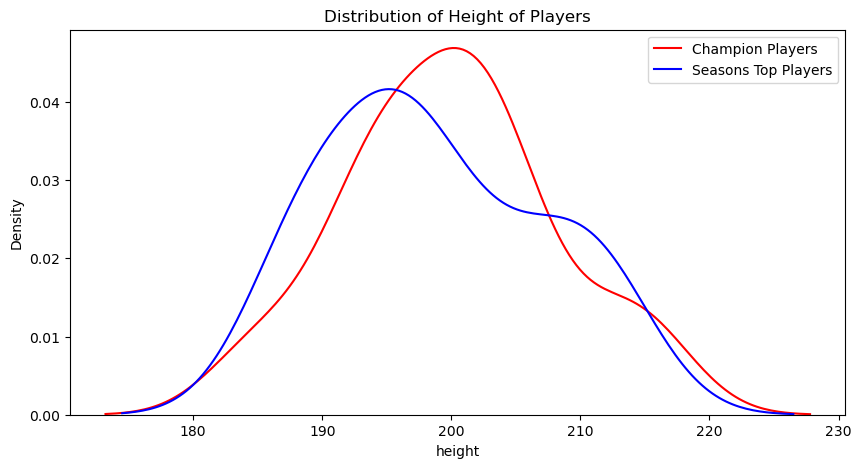

In [11]:
fig = plt.figure(figsize=(10, 5))

sns.kdeplot(height_champ['height'], color='r', label='Champion Players')
sns.kdeplot(height_season['height'], color='b', label='Seasons Top Players')

plt.legend()
plt.title('Distribution of Height of Players')

Text(0.5, 1.0, 'Distribution of Experience of Players')

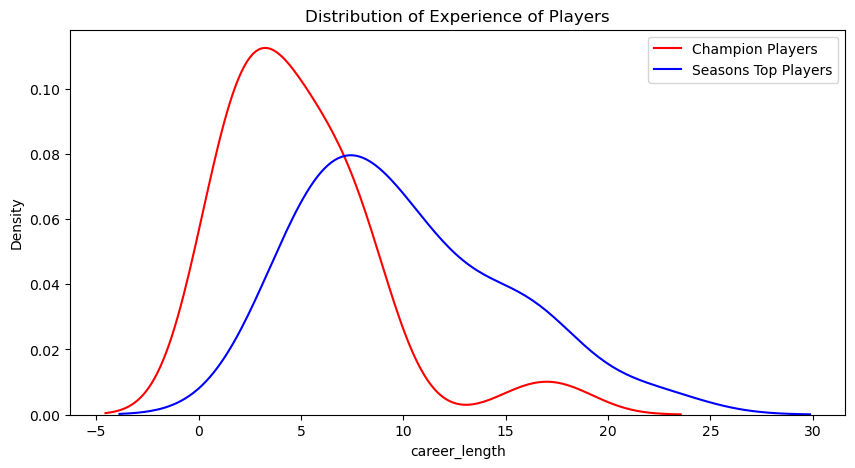

In [12]:
fig = plt.figure(figsize=(10, 5))

sns.kdeplot(exprience_champ['career_length'], color='r', label='Champion Players')
sns.kdeplot(exprience_season['career_length'], color='b', label='Seasons Top Players')

plt.legend()
plt.title('Distribution of Experience of Players')

## Query 3: Top PG Players

In [21]:
pd.read_sql("""SELECT player, COUNT(mvp_vote_results.player_id) AS number_presence FROM mvp_vote_results
            INNER JOIN players ON mvp_vote_results.player_id = players.player_id
            INNER JOIN player_position on players.player_id = player_position.player_id
            INNER JOIN positions on player_position.position_id = positions.position_id
            WHERE position_name = 'Point Guard' and (season = '2019-20' OR season = '2020-21' OR season = '2021-22' OR season = '2022-23' OR season = '2023-24')
            GROUP BY player 
            ORDER BY number_presence DESC
            LIMIT 3
            """, conn)

,player,number_presence
0,Luka Dončić,5
1,Stephen Curry,3
2,Chris Paul,3


## Hypothesis 1

In [23]:
height_weight_2024 = pd.read_sql("""SELECT height/weight FROM season_top_players
                                    INNER JOIN players ON season_top_players.player_id = players.player_id
                                    WHERE rank <= 20 AND
                                    season <= 2024 AND season >= 2023
                                    """, conn)

In [24]:
height_weight_2022 = pd.read_sql("""SELECT height/weight FROM season_top_players
                                    INNER JOIN players ON season_top_players.player_id = players.player_id
                                    WHERE rank <= 20 AND
                                    season <= 2022 AND season >= 2021
                                    """, conn)

First we check if the data is normally distributed.

In [16]:
shapiro(height_weight_2022)

ShapiroResult(statistic=0.9776196479797363, pvalue=0.6017729043960571)

In [17]:
shapiro(height_weight_2024)

ShapiroResult(statistic=0.9799590706825256, pvalue=0.6880320906639099)

since the null hypothesis wasn't rejected, we assume that the data is normally distributed. so we will use T-test.

In [18]:
ttest_ind(height_weight_2024['height/weight'], height_weight_2022['height/weight'], alternative='greater')

TtestResult(statistic=-0.06476603934138311, pvalue=0.525737007855974, df=78.0)

since p-value is greater than 0.05, we cannot conclude that the height to weight ratio has increased. In fact, it looks like that they are almost equal.

In [27]:
ttest_ind(height_weight_2024['height/weight'], height_weight_2022['height/weight'])

TtestResult(statistic=-0.06476603934138311, pvalue=0.948525984288052, df=78.0)

Text(0.5, 1.0, 'Boxplot of Height to Weight Ratio')

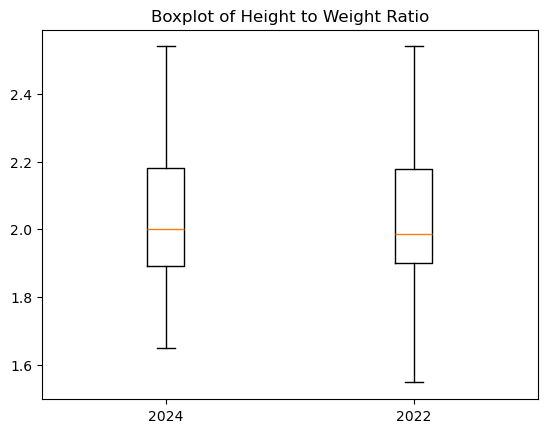

In [42]:
plt.boxplot([height_weight_2024['height/weight'], height_weight_2022['height/weight']], tick_labels=[2024, 2022])
plt.title('Boxplot of Height to Weight Ratio')

## Hypothesis 2

In [ ]:
champ_2025 = pd.read_sql("""SELECT career_length/age FROM players
                            WHERE player_id IN (SELECT player_id FROM team_players
                            WHERE season = '2024-25' or season = '2023-24')
                            """, conn)

In [46]:
champ_2023 = pd.read_sql("""SELECT career_length/age FROM players
                            WHERE player_id IN (SELECT player_id FROM team_players
                            WHERE season = '2022-23' or season = '2021-22')
                            """, conn)

first we check if data is normally distributed

In [47]:
shapiro(champ_2025)

ShapiroResult(statistic=0.9225117640367246, pvalue=0.013230908656187894)

In [48]:
shapiro(champ_2023)

ShapiroResult(statistic=0.9382169373652066, pvalue=0.06029838300764028)

since data is not normally distributed, we will Mannwhitneyu test.

In [58]:
mannwhitneyu(champ_2025['career_length/age'], champ_2023['career_length/age'], alternative='greater')

MannwhitneyuResult(statistic=354.0, pvalue=0.9987540422007227)

since p-value is greater than 0.05, we are not able to conclude that careerlength to age ratio has increased.

Text(0.5, 1.0, 'Boxplot of Career length to Age Ratio')

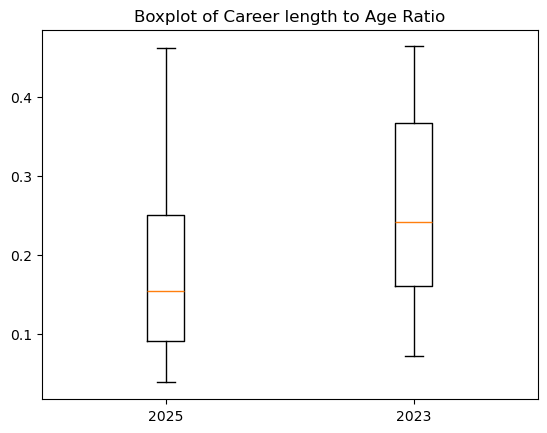

In [67]:
plt.boxplot([champ_2025['career_length/age'], champ_2023['career_length/age']], tick_labels=[2025, 2023])
plt.title('Boxplot of Career length to Age Ratio')

in fact, it is the opposite.

In [68]:
mannwhitneyu(champ_2025['career_length/age'], champ_2023['career_length/age'], alternative='less')

MannwhitneyuResult(statistic=354.0, pvalue=0.0012952983860011963)

## Hypothesis 3

In [ ]:

hyp3_var = pd.read_sql("""
SELECT
    tp.season,
    p.player,
    p.age,
    CAST(substr(tp.season, 1, 4) AS INTEGER) AS season_year,
    CAST(substr(p.nba_debut, -4) AS INTEGER) AS debut_year,
    (CAST(substr(tp.season, 1, 4) AS INTEGER)
     - CAST(substr(p.nba_debut, -4) AS INTEGER)) AS experience,
    1.0 * (
        CAST(substr(tp.season, 1, 4) AS INTEGER)
        - CAST(substr(p.nba_debut, -4) AS INTEGER)
    ) / p.age AS innate_ability
FROM team_players tp
JOIN players p
  ON p.player_id = tp.player_id
WHERE substr(tp.season, 1, 4) IN ('2023', '2024');
""", conn)
hyp3_var.head()


,season,player,age,season_year,debut_year,experience,innate_ability
0,2024-25,Branden Carlson,26.0,2024,2024,0,0.000000
1,2024-25,Alex Caruso,31.0,2024,2017,7,0.225806
2,2024-25,Ousmane Dieng,22.0,2024,2022,2,0.090909
3,2024-25,Luguentz Dort,26.0,2024,2019,5,0.192308
4,2024-25,Alex Ducas,25.0,2024,2024,0,0.000000


In [ ]:

clean = hyp3_var[
    (hyp3_var["age"] > 0) &
    (hyp3_var["experience"] >= 0)].copy()



In [ ]:
from scipy.stats import ttest_ind

g2024 = clean[clean["season_year"] == 2024]["innate_ability"]
g2023 = clean[clean["season_year"] == 2023]["innate_ability"]

ttest_ind(g2024, g2023, equal_var=False)

TtestResult(statistic=-1.9109242689291057, pvalue=0.06562017554214718, df=29.973749842982784)



- **t-statistic:** -1.91  
- **p-value:** 0.0656  

Since the p-value is greater than 0.05, the null hypothesis is not rejected.  
There is no statistically significant evidence that players in recent champion seasons have higher innate ability.

## hypothesis by us


In [61]:
hyp1 = pd.read_sql("""
SELECT
    colleges.college_name,
    players.points AS career_points
FROM players
JOIN player_college ON players.player_id = player_college.player_id
JOIN colleges ON colleges.college_id = player_college.college_id
WHERE players.points IS NOT NULL
""", conn)
hyp1

,college_name,career_points
0,Duke,5.7
1,Iowa,9.0
2,UCLA,24.6
3,LSU,14.6
4,Michigan,7.8
...,...,...
5358,None,6.0
5359,Kent,0.3
5360,Duquesne,2.2
5361,None,15.0


H0: Performance of players across different universities are similar.

H1: At least one university has a different performance.

In [ ]:
counts = hyp1["college_name"].value_counts()


valid_colleges = counts[counts >= 20].index

hyp1_filtered = hyp1[hyp1["college_name"].isin(valid_colleges)]


groups = [
    group["career_points"].values
    for _, group in hyp1_filtered.groupby("college_name")
]

anova_result = f_oneway(*groups)
anova_result

F_onewayResult(statistic=1.556986392257554, pvalue=0.0009672510472823093)

Since the p-value is less than 0.05, we reject the null hypothesis and conclude that there is a statistically significant difference in the average points scored by players from different colleges.

## hypothesis by us 2

In [32]:
star_seasons = pd.read_sql("""
SELECT
    tps.player_id,
    p.player,
    tps.season,
    tps.points
FROM season_top_players tps
JOIN players p ON p.player_id = tps.player_id
WHERE tps.points IS NOT NULL
""", conn)
star_seasons

,player_id,player,season,points
0,3251,George Mikan*,1950,1865.0
1,1835,Alex Groza,1950,1496.0
2,532,Frankie Brian,1950,1138.0
3,5388,Max Zaslofsky,1950,1115.0
4,2943,Ed Macauley*,1950,1081.0
...,...,...,...,...
25238,1414,Tosan Evbuomwan,2026,0.0
25239,1712,Vladislav Goldin,2026,0.0
25240,2057,Chucky Hepburn,2026,0.0
25241,2998,Chris Mañon,2026,0.0


In [35]:
def decade(year):
    if 1970 <= int(year) <= 1989:
        return "old"
    elif 2000 <= int(year) <= 2019:
        return "new"
    else:
        return None

star_seasons["decade_group"] = star_seasons["season"].apply(decade)
star_seasons = star_seasons.dropna(subset=["decade_group"])

In [ ]:
max_pts = star_seasons.groupby("player_id")["points"].max()

star_seasons = star_seasons.join(max_pts, on="player_id", rsuffix="_max")

star_seasons["is_peak"] = star_seasons["points"] >= 0.8 * star_seasons["points_max"]

In [38]:
peak_years = (
    star_seasons[star_seasons["is_peak"]]
    .groupby(["player_id", "decade_group"])
    .size()
    .reset_index(name="peak_years")
)

In [39]:
peak_summary = peak_years.groupby("decade_group")["peak_years"].mean()
peak_summary

decade_group
new    1.705224
old    1.726244
Name: peak_years, dtype: float64

In [ ]:
old = peak_years[peak_years["decade_group"] == "old"]["peak_years"]
new = peak_years[peak_years["decade_group"] == "new"]["peak_years"]

ttest_ind(new, old, equal_var=False)

TtestResult(statistic=-0.4783887550640737, pvalue=0.6324105018255668, df=2829.0387068690284)

Since the p-value is more than 0.05, there is no statistically significant difference in the average number of peak years between the two groups of players.

## EDA

In [ ]:
df_city_mvp = pd.read_sql("""
SELECT
    p.born_city_country AS city,
    COUNT(*) AS mvp_count
FROM mvp m
JOIN players p
  ON p.player_id = m.player_id
WHERE p.born_city_country IS NOT NULL
GROUP BY p.born_city_country
ORDER BY mvp_count DESC
""", conn)

df_city_mvp.head(10)

,city,mvp_count
0,"New York, New York us",7
1,"Akron, Ohio us",6
2,"Philadelphia, Pennsylvania us",5
3,"Monroe, Louisiana us",5
4,"Brooklyn, New York us",5
5,"West Baden, Indiana us",3
6,"Sombor, Serbia rs",3
7,"Petersburg, Virginia us",3
8,"Lansing, Michigan us",3
9,"Summerfield, Louisiana us",2


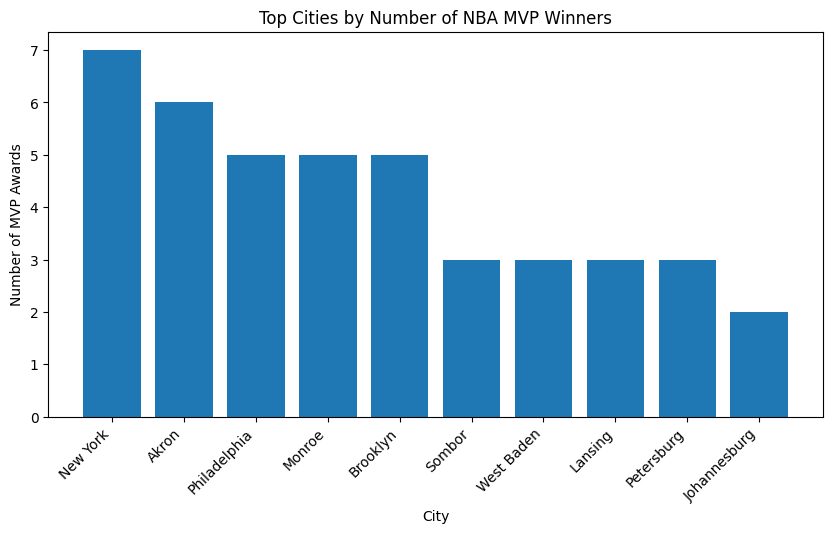

In [ ]:
df_city_mvp["city_clean"] = df_city_mvp["city"].str.split(",").str[0]
df_city_mvp_clean = (
    df_city_mvp
    .groupby("city_clean", as_index=False)["mvp_count"]
    .sum()
    .sort_values("mvp_count", ascending=False)
)
df_city_mvp_clean = (
    df_city_mvp
    .groupby("city_clean", as_index=False)["mvp_count"]
    .sum()
    .sort_values("mvp_count", ascending=False)
)
top_cities = df_city_mvp_clean.head(10)

plt.figure(figsize=(10,5))
plt.bar(top_cities["city_clean"], top_cities["mvp_count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top Cities by Number of NBA MVP Winners")
plt.ylabel("Number of MVP Awards")
plt.xlabel("City")
plt.show()

In [ ]:
df_age_points = pd.read_sql("""
SELECT
    age,
    AVG(points) AS avg_points
FROM players
WHERE age IS NOT NULL
  AND points IS NOT NULL
GROUP BY age
ORDER BY age
""", conn)

df_age_points.head()

,age,avg_points
0,19.0,7.371429
1,20.0,6.690000
2,21.0,7.217143
3,22.0,7.407692
4,23.0,6.485507


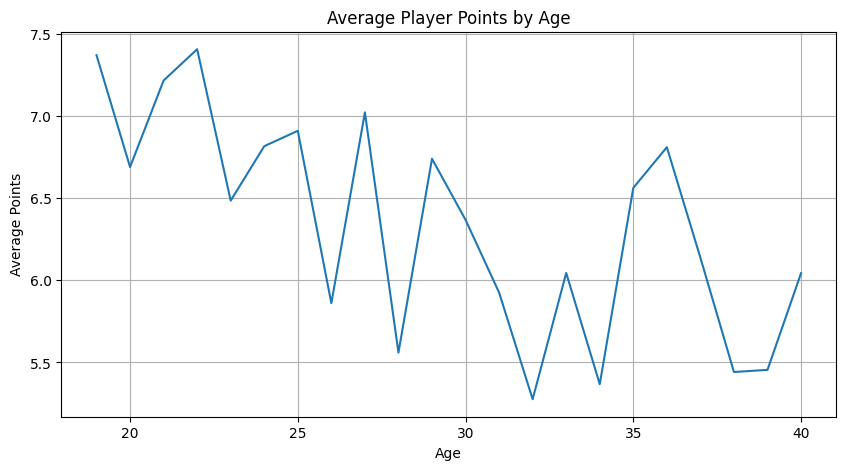

In [ ]:
df_age_points = df_age_points[
    (df_age_points["age"] >= 18) &
    (df_age_points["age"] <= 40)
]

plt.figure(figsize=(10,5))
plt.plot(df_age_points["age"], df_age_points["avg_points"])
plt.xlabel("Age")
plt.ylabel("Average Points")
plt.title("Average Player Points by Age")
plt.grid(True)
plt.show()